In [ ]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from stat_functions import *

In [2]:
scenario = "linear_reward"
trial_number = 10
save_plot = False

In [3]:
base_path = os.path.sep.join(os.path.abspath("__file__").split(os.path.sep)[:-2])
plot_path = os.path.join(base_path,"results",scenario,"plots")
folder_root = "STDP"

sys.path.insert(0, os.path.join(base_path,"code/functions"))
os.makedirs(plot_path, exist_ok=True)

target_seed = np.arange(10)

from global_variables import *
from linear_reward_variables import *
from linear_reward_functions import *
from plots import *
from stat_functions import *

ref_path = os.path.join(data_path,folder_root+str(target_seed[0]))
sys.path.append(ref_path)


In [ ]:
load_lap = 3000
CA3_weights = np.zeros((num_CA3_neurons,num_CA3_neurons,len(target_seed)))

for ii,seed in enumerate(target_seed):
    CA3_weights[:,:,ii] = np.load(os.path.join(data_path,folder_root+str(seed),"lap_%d.npz"%(load_lap)))["w_CA3_CA3"]


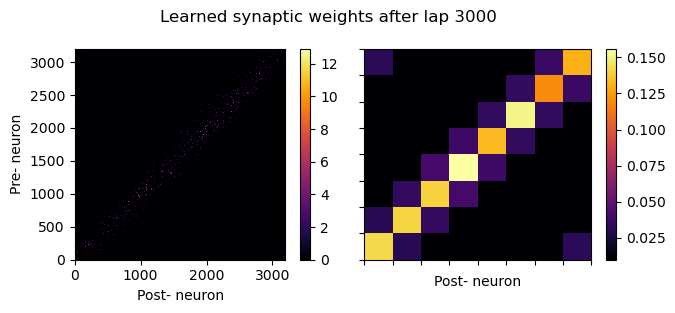

In [83]:
pop_per_unit = 1
n_pops = num_state_total * pop_per_unit
CA3_mean_wmx_arr = np.zeros((n_pops,n_pops,len(target_seed)))
for seed in range(len(target_seed)):
    CA3_mean_wmx_arr[:,:,seed] = average_weight(CA3_weights[:,:,seed], n_pops, n_pops)

CA3_mean_wmx = CA3_mean_wmx_arr.mean(-1)

fig, axs = plt.subplots(1,2,figsize=(7, 3)); plt.xlabel("Post- neuron")

i = axs[0].imshow(CA3_weights[:,:,1], cmap="inferno", origin="lower", interpolation="nearest")  # nS conversion
fig.colorbar(i)
fig.suptitle("Learned synaptic weights after lap %d"%load_lap)
axs[0].set_xlabel("Post- neuron")

fig, axs[1] = plot_heatmap(CA3_mean_wmx, fig=fig, ax=axs[1],title="")
axs[1].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_xticklabels([])
axs[1].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_yticklabels([])
axs[0].set_ylabel("Pre- neuron"); axs[1].set_xlabel("Post- neuron")

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"avg_hippocampal_weights_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

In [75]:
unit_gran = 4; state_window = 4
target_state = np.arange(num_state_total)
n_units = unit_gran * len(target_state)        # 32 binned units per seed
half    = state_window * unit_gran             # center column index

target_laps = [500,1000,1500,2000,2400,2800]

CA3_aligned = np.zeros((n_units, state_window*len(target_state)+1, len(target_laps), len(target_seed)))
CA3_aligned_ref = np.zeros((n_units, state_window*len(target_state)+1, len(target_seed)))
for ii, seed in enumerate(target_seed):
    for ll, lap in enumerate(target_laps):
        W_CA3 = np.load(os.path.join(data_path,folder_root+str(seed),"lap_%d.npz"%(lap)))["w_CA3_CA3"]
        CA3_mean_wmx = average_weight(W_CA3, n_units, n_units)
        CA3_aligned[:,:,ll,ii]  = extract_aligned_activity(
            CA3_mean_wmx, np.argmax(CA3_mean_wmx, axis=1), unit_gran*state_window)
        del CA3_mean_wmx

    CA3_mean_wmx = average_weight(CA3_weights_ref[:, :, ii], n_units, n_units)
    CA3_aligned_ref[:,:,ii]  = extract_aligned_activity(
        CA3_mean_wmx, np.argmax(CA3_mean_wmx, axis=1), unit_gran*state_window)
    del CA3_mean_wmx

avg_CA3_aligned = CA3_aligned.mean(-1)
avg_CA3_aligned_ref = CA3_aligned_ref.mean(-1)

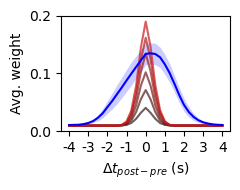

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2))

colors = create_gradient([0.2,0.1,0.1],[0.8,0.1,0.1],len(target_laps))
for ll in range(len(target_laps)):
    data = avg_CA3_aligned[:,:,ll]
    ax.plot(np.arange(data.shape[1]),data.mean(0),color=colors[ll],alpha=0.7)

ax = plot_shaded(np.arange(avg_CA3_aligned_ref.shape[1]),avg_CA3_aligned_ref.mean(0),avg_CA3_aligned_ref.std(0),ax,color='blue')
ax.set_xlabel(r"$\Delta t_{post-pre}$ (s)"); ax.set_xticks(np.arange(0, state_window*num_state_total+1, state_window))
ax.set_xticklabels(np.arange(0, num_state_total+1)-num_state_total//2)
ax.set_ylabel("Avg. weight"); ax.set_ylim([0,0.2]); ax.set_yticks([0,0.1,0.2])

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"Avg_weight_sSTDP.svg"))
plt.show()

In [ ]:
from run_offline import find_replay_onset

trial_names = ["trial%d" % i for i in range(trial_number)]
onset_laps_ref = find_replay_onset(trial_names=trial_names, descending=False)
print(onset_laps_ref)

trial_names = ["STDP%d" % i for i in range(trial_number)]
onset_laps = find_replay_onset(trial_names=trial_names)
print(onset_laps)


STDP0 (coarse):  11%|█         | 1/9 [00:04<00:35,  4.45s/it]

STDP0: lap 3000 -> burst


STDP0 (coarse):  11%|█         | 1/9 [00:08<01:07,  8.43s/it]

STDP0: lap 2800 -> no burst


STDP0: search_lap 2900 (fraction 0.500) -> burst
STDP0: search_lap 2850 (fraction 0.250) -> no burst
STDP0: search_lap 2875 (fraction 0.375) -> no burst
STDP0: search_lap 2887 (fraction 0.435) -> burst
STDP0: search_lap 2881 (fraction 0.405) -> burst
STDP0: search_lap 2878 (fraction 0.390) -> no burst
STDP0: search_lap 2879 (fraction 0.395) -> burst


...

STDP9 (coarse):  22%|██▏       | 2/9 [00:08<00:28,  4.03s/it]

STDP9: lap 2800 -> burst


STDP9 (coarse):  22%|██▏       | 2/9 [00:12<00:42,  6.03s/it]

STDP9: lap 2600 -> no burst


STDP9: search_lap 2700 (fraction 0.500) -> no burst
STDP9: search_lap 2750 (fraction 0.750) -> burst
STDP9: search_lap 2725 (fraction 0.625) -> no burst
STDP9: search_lap 2737 (fraction 0.685) -> no burst
STDP9: search_lap 2743 (fraction 0.715) -> no burst
STDP9: search_lap 2746 (fraction 0.730) -> no burst
STDP9: search_lap 2748 (fraction 0.740) -> no burst
STDP9: search_lap 2749 (fraction 0.745) -> no burst
{'STDP0': 2879, 'STDP1': 2833, 'STDP2': 2674, 'STDP3': 2697, 'STDP4': 2735, 'STDP5': 2753, 'STDP6': 2622, 'STDP7': 2801, 'STDP8': 2701, 'STDP9': 2750}


In [ ]:
onset_laps = np.zeros((2,trial_number),dtype=int)
for trial in range(trial_number):
    onset_laps[0,trial] = np.load(os.path.join(data_path,"STDP"+str(trial),"replay_onset.npz"),allow_pickle=True)["onset_lap"]
    onset_laps[1,trial] = np.load(os.path.join(data_path,"trial"+str(trial),"replay_onset.npz"),allow_pickle=True)["onset_lap"]
    
onset_laps

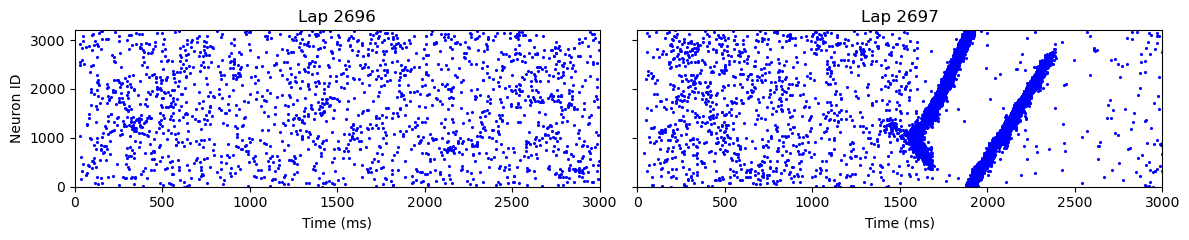

In [33]:
example_seed = target_seed[3]

ff = np.load(os.path.join(data_path,folder_root+str(example_seed),"replay_onset.npz"),allow_pickle=True)

fig, axs = plt.subplots(1,2,figsize=(12,2.5))
axs[0].set_title("Lap %d"%(onset_laps[example_seed]-1))
plot_spike(ff['before_spk_times'], ff['before_spk_neurons'], np.arange(num_CA3_neurons), zoom_to=3000, ax=axs[0])
axs[0].set_ylim([0,num_CA3_neurons])
axs[1].set_title("Lap %d"%onset_laps[example_seed])
plot_spike(ff['onset_spk_times'], ff['onset_spk_neurons'], np.arange(num_CA3_neurons), zoom_to=3000, ax=axs[1])
axs[1].set_ylabel(None); axs[1].set_yticklabels([]); axs[1].set_ylim([0,num_CA3_neurons])

fig.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Spontaneous_activity_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

In [ ]:
# a=np.array([[   1,    1,    1,    2,    2,    2,    2,    2,    2,    2],
#        [2879, 2833, 2674, 2697, 2735, 2753, 2622, 2801, 2701, 2750]])
# a=onset_laps
# onset_laps[0] = a[1]
# onset_laps[1] = a[0]

sSTDP vs BTSP onset lap: p=1.795e-15, p_fdr=1.795e-15, d_z=35.495, 95% CI [2687.522, 2798.078]


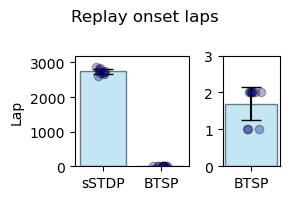

In [92]:
x_positions = [0,1]
# Calculate summary metrics
means = [np.mean(data) for data in onset_laps]
std_devs = [np.std(data) for data in onset_laps]

# 2. Initialize the plot
fig, axs = plt.subplots(1,2,figsize=(3, 2), gridspec_kw={'width_ratios': [2, 1]})

# Draw the main bar chart
# 'alpha' softens the fill color so individual data points stay visible
axs[0].bar(x_positions, means, yerr=std_devs, capsize=7, color='skyblue', 
        edgecolor='black', alpha=0.5, label='Mean ± SD')

# Add individual data points with jitter
for idx, group_data in enumerate(onset_laps):
    jitter = np.random.normal(0, 0.1, size=len(group_data))
    x_jittered = x_positions[idx] + jitter

    axs[0].scatter(x_jittered, group_data, color='darkblue', alpha=0.3, 
                edgecolor='black', zorder=3)

axs[1].bar([0], means[1], yerr=std_devs[1], capsize=7, color='skyblue', 
        edgecolor='black', alpha=0.5, label='Mean ± SD')
x_jittered = np.random.normal(0, 0.1, size=len(onset_laps[1]))

axs[1].scatter(x_jittered, onset_laps[1], color='darkblue', alpha=0.3, 
                edgecolor='black', zorder=3)
axs[1].set_ylim([0,3]); axs[1].set_xticks([0]); axs[1].set_xticklabels(["BTSP"])

# 3. Formatting and styling
axs[0].set_xticks(x_positions, ['sSTDP','BTSP'])
axs[0].set_ylabel('Lap'); axs[0].set_ylim([0,3200])
axs[0].set_yticks(np.arange(0,3001,1000))
plt.suptitle('Replay onset laps')
plt.tight_layout()

t_sym, p_sym = stats.ttest_rel(onset_laps[0], onset_laps[1])
_, p_fdr_sym, _, _ = multipletests([p_sym], method='fdr_bh')
d_sym = cohens_d_paired(onset_laps[0], onset_laps[1])
ci_lo, ci_hi = ci_paired(onset_laps[0], onset_laps[1])
print(f"sSTDP vs BTSP onset lap: p={p_sym:.4g}, p_fdr={p_fdr_sym[0]:.4g}, "
      f"d_z={d_sym:.3f}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}]")

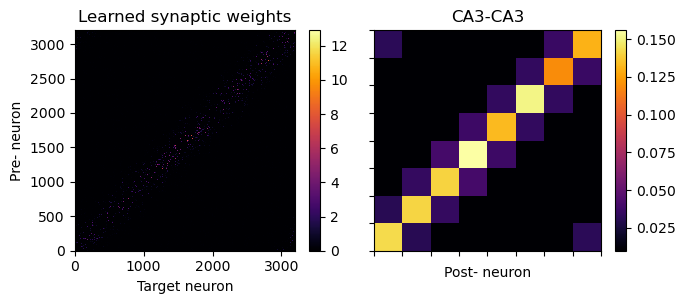

In [26]:
ff = np.load('/home/suheecho/BTSP/Rapid_Learning_Cognitive_Map/results/linear_reward/STDP1/replay_onset.npz')

In [27]:
ff['slice_idx']

array([], dtype=float64)